In [14]:
import torch

x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

In [15]:
x.requires_grad_(True)  # 等价于x=torch.arange(4.0,requires_grad=True)
x.grad  # 默认值是None

In [16]:
y = 2 * torch.dot(x, x)
y

tensor(28., grad_fn=<MulBackward0>)

In [17]:
y.backward()
x.grad

tensor([ 0.,  4.,  8., 12.])

In [63]:
x.grad == 4 * x

tensor([ True, False, False, False])

In [65]:
# 在默认情况下，PyTorch会累积梯度，我们需要清除之前的值
x.grad.zero_()
y = x.sum()
y.backward()
x.grad

tensor([2., 2., 2., 2.])

In [47]:
x.grad.zero_()
y = x * x
u = y.detach() #u 是一个和 y 数值相同的张量，但是它不是 x 的函数了，而是被当作一个固定常数参与后续计算。
z = u * x

z.sum().backward()
u
# x.grad == u

tensor([0., 1., 4., 9.])

In [48]:
x.grad.zero_()
y.sum().backward()
print(x.grad==2*x)

tensor([True, True, True, True])


In [61]:
def f(a):
    b = a * 2
    while b.norm() < 1000:
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c

In [62]:
a = torch.randn(size=(), requires_grad=True)
print(a)
d = f(a)
d.backward()

tensor(0.4473, requires_grad=True)
tensor(1832.0554, grad_fn=<MulBackward0>) tensor(1832.0554, grad_fn=<SumBackward0>)


In [56]:
a.grad == d / a

tensor(True)

In [69]:
import torch


def f(x):
    y = x * 2

    # 控制流1：while循环
    while y < 10:
        y = y * 2

    # 控制流2：if判断
    if y > 20:
        z = y
    else:
        z = 3 * y

    return z


# 定义输入
x = torch.tensor(1.0, requires_grad=True)

# 前向计算
z = f(x)

print("z =", z)


# 反向传播
z.backward()

print("x的梯度 =", x.grad)

z = tensor(48., grad_fn=<MulBackward0>)
x的梯度 = tensor(48.)


tensor([-1.7485e-07,  9.9999e-03,  1.9998e-02,  ..., -2.6368e-02,
        -1.6370e-02, -6.3708e-03], grad_fn=<SinBackward0>)


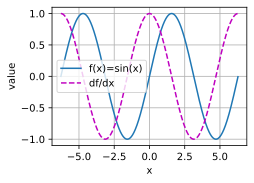

In [71]:
import torch
from d2l import torch as d2l


# 定义x，并开启梯度
x = torch.arange(-2*torch.pi, 2*torch.pi, 0.01, requires_grad=True)


# 定义函数 f(x)=sin(x)
y = torch.sin(x)


# 求导
y.sum().backward()


# x.grad就是df/dx
dy_dx = x.grad


# 绘图
d2l.plot(
    x.detach().numpy(),
    [y.detach().numpy(), dy_dx.detach().numpy()],
    'x',
    'value',
    legend=['f(x)=sin(x)', "df/dx"]
)

In [72]:
import torch

print(torch.__version__)


2.13.0+cpu
